In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

np.random.seed(42)

In [4]:
# Training set
X_train, y_train = make_moons(n_samples=1500, noise=0.15, random_state=42)

# Test set
X_test, y_test = make_moons(n_samples=500, noise=0.15, random_state=43)
y_train = y_train.reshape(-1,1)
y_test = y_test.reshape(-1,1)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (1500, 2)
Test shape: (500, 2)


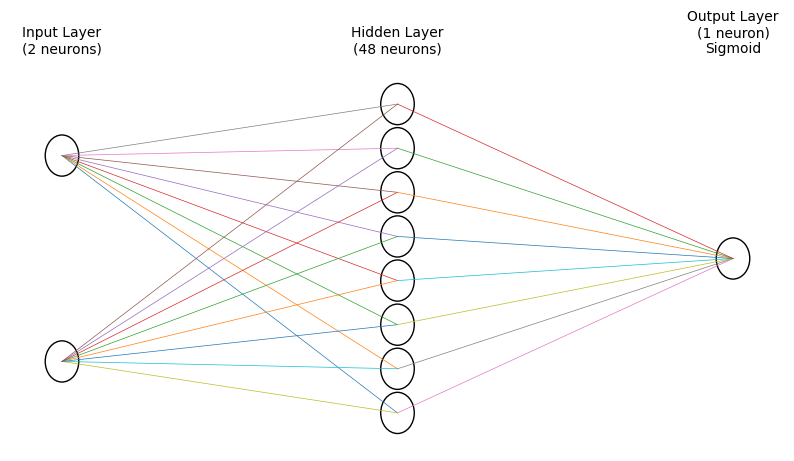

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def draw_nn():
    fig, ax = plt.subplots(figsize=(10,5))

    # Layer positions
    input_layer_x = 1
    hidden_layer_x = 5
    output_layer_x = 9

    # Input neurons (2)
    input_y = [3,1]

    # Hidden neurons (display only 8 but label as 48)
    hidden_y = np.linspace(0.5,3.5,8)

    # Output neuron
    output_y = [2]

    # Draw input neurons
    for y in input_y:
        circle = plt.Circle((input_layer_x,y),0.2,fill=False)
        ax.add_patch(circle)

    # Draw hidden neurons
    for y in hidden_y:
        circle = plt.Circle((hidden_layer_x,y),0.2,fill=False)
        ax.add_patch(circle)

    # Draw output neuron
    for y in output_y:
        circle = plt.Circle((output_layer_x,y),0.2,fill=False)
        ax.add_patch(circle)

    # Connections input → hidden
    for y1 in input_y:
        for y2 in hidden_y:
            ax.plot([input_layer_x,hidden_layer_x],[y1,y2],linewidth=0.5)

    # Connections hidden → output
    for y2 in hidden_y:
        ax.plot([hidden_layer_x,output_layer_x],[y2,output_y[0]],linewidth=0.5)

    # Labels
    ax.text(input_layer_x,4,"Input Layer\n(2 neurons)",ha='center')
    ax.text(hidden_layer_x,4,"Hidden Layer\n(48 neurons)",ha='center')
    ax.text(output_layer_x,4,"Output Layer\n(1 neuron)\nSigmoid",ha='center')

    ax.axis('off')
    plt.show()

draw_nn()

In [6]:
def matmul(A, B):
    rows = A.shape[0]
    cols = B.shape[1]
    result = np.zeros((rows, cols))
    for i in range(rows):
        for j in range(cols):
            result[i, j] = np.sum(A[i, :] * B[:, j])
    return result

In [7]:
def binary_cross_entropy(y_true, y_pred):
    eps = 1e-9
    return -np.mean(
        y_true*np.log(y_pred+eps) +
        (1-y_true)*np.log(1-y_pred+eps)
    )

In [8]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

class NeuralNetwork:
    def __init__(self, activation="relu", lr=0.01):
        self.lr = lr
        self.activation = activation
        np.random.seed(0)
        self.W1 = np.random.randn(2,48)*0.1
        self.b1 = np.zeros((1,48))
        self.W2 = np.random.randn(48,1)*0.1
        self.b2 = np.zeros((1,1))
    
    def activate(self,x):
        if self.activation == "sigmoid":
            return 1/(1+np.exp(-x))
        
        if self.activation == "tanh":
            return np.tanh(x)
        
        if self.activation == "relu":
            return np.maximum(0,x)
        
        if self.activation == "leaky_relu":
            return np.where(x>0,x, 0.01*x)
    
    
    def activate_derivative(self,x):

        if self.activation == "sigmoid":
            s = 1/(1+np.exp(-x))
            return s*(1-s)
        
        if self.activation == "tanh":
            return 1 - np.tanh(x)**2
        
        if self.activation == "relu":
            return (x>0).astype(float)
        
        if self.activation == "leaky_relu":
            dx = np.ones_like(x)
            dx[x<0] = 0.01
            return dx
    
    
    def forward(self,X):
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = self.activate(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = sigmoid(self.Z2)
        return self.A2
    
    
    def backward(self,X,y):
        
        m = X.shape[0]
        
        dZ2 = self.A2 - y
        dW2 = (self.A1.T @ dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m
        
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * self.activate_derivative(self.Z1)
        
        dW1 = (X.T @ dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m
        
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
    
    
    def train(self, X, y, iterations=10000, batch_size=64):
        losses = []
        n = X.shape[0]
        for i in range(iterations):
            idx = np.random.choice(n, batch_size)
            X_batch = X[idx]
            y_batch = y[idx]
            y_pred = self.forward(X_batch)
            loss = binary_cross_entropy(y_batch, y_pred)
            self.backward(X_batch, y_batch)
            if i % 200 == 0:
                losses.append(loss)
        return losses
    
    
    def predict(self,X):
        probs = self.forward(X)
        return (probs > 0.5).astype(int)

In [9]:
activations = ["sigmoid", "tanh", "relu", "leaky_relu"]

models = {}
losses = {}
accuracies = {}

def accuracy_score(y_true, y_pred):
    correct = np.sum(y_true == y_pred)
    total = len(y_true)
    acc = correct / total
    return acc

for act in activations:
    np.random.seed(0)
    model = NeuralNetwork(activation=act, lr=0.01)
    loss_history = model.train(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    models[act] = model
    losses[act] = loss_history
    accuracies[act] = acc

In [10]:
print("Final Test Accuracy\n")
print("{:<12} {:<10}".format("Activation", "Accuracy"))
for act in activations:
    print("{:<12} {:.4f}".format(act, accuracies[act]))

Final Test Accuracy

Activation   Accuracy  
sigmoid      0.8760
tanh         0.8660
relu         0.8720
leaky_relu   0.8720


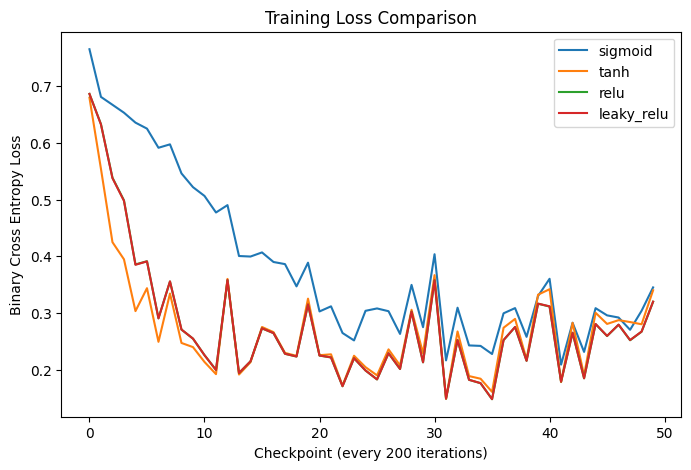

In [11]:
plt.figure(figsize=(8,5))
for act in activations:
    plt.plot(losses[act], label=act)
plt.xlabel("Checkpoint (every 200 iterations)")
plt.ylabel("Binary Cross Entropy Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

In [12]:
def plot_decision_boundary(model, X, y, ax, title):
    
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid)
    preds = preds.reshape(xx.shape)
    ax.contourf(xx, yy, preds, alpha=0.3)
    ax.scatter(X[:,0], X[:,1], c=y.squeeze(), s=10)
    ax.set_title(title)

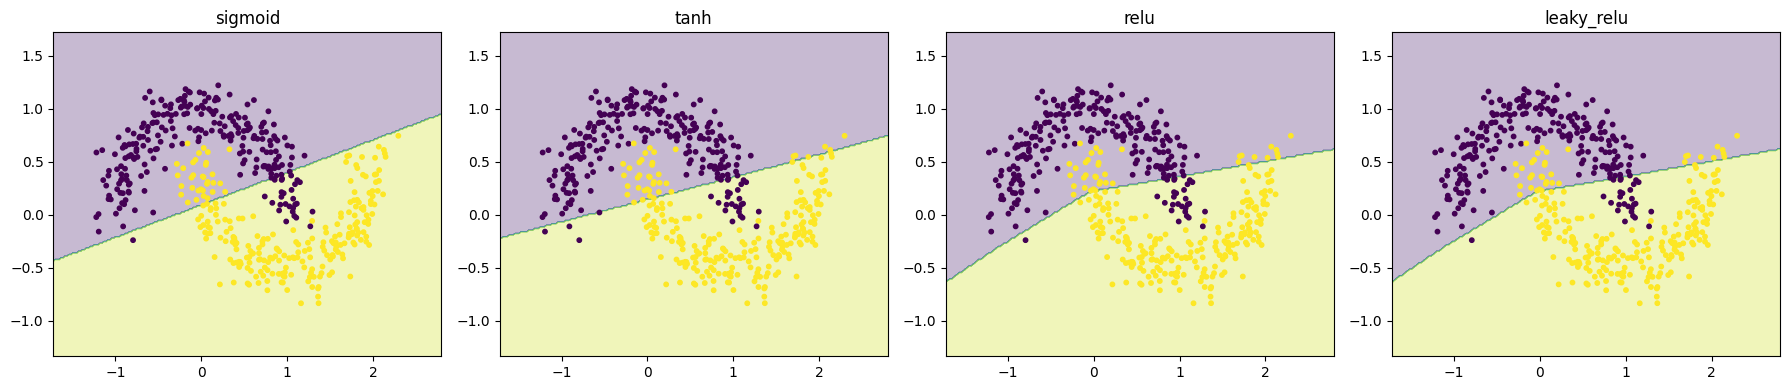

In [13]:
fig, axs = plt.subplots(1,4, figsize=(18,4))
for ax, act in zip(axs, activations):
    plot_decision_boundary(models[act], X_test, y_test, ax, act)

plt.tight_layout()
plt.show()